<a href="https://colab.research.google.com/github/DivyankBaluni/Global-Terrorism-Analysis-and-ML/blob/main/global_terrorism_pattern_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌏 Global Terrorism Pattern Analysis
## using the Global Terrorism Database (GTD)

---

> **PROJECT TYPE:** Exploratory Data Analysis (EDA) and ML Models Implementation  
> **Dataset:** Global Terrorism Database (GTD)

---


#👤**Contribution** : **Individual**
> **Name** : Divyank Baluni

# 📋 **Project Summary**

---

The **Global Terrorism Database (GTD)** is one of the most comprehensive open-source databases
on terrorist events worldwide. Maintained by **START** at the University of Maryland, it catalogues
over **181,691** incidents between **1970–2017** across **205 countries**, with **135 attributes** per record.

This project performs in-depth **Exploratory Data Analysis (EDA)** to uncover global patterns in
the frequency, geography, methodology, and perpetrators of terrorist activity — tracing nearly
five decades of evolution from Cold War-era violence to the 2010s extremist surge.

> **Middle East & North Africa** and **South Asia** account for **53%+** of all incidents.
> Bombing/explosion is the most prevalent attack type (**49%**), peaking at **16,903 incidents in 2014**.

The dataset records over **411,868 fatalities** and **523,869 injuries**, with 2014 alone
accounting for more than **44,000 deaths**.

---

## 📊 Dataset Overview

| Metric | Value |
|---|---|
| Total Incidents | 181,691 |
| Total Fatalities | 411,868 |
| Total Wounded | 523,869 |
| Countries Affected | 205 |
| Time Period | 1970 – 2017 |
| Total Columns | 135 |

---

## 🤖 ML Models Implemented

| Model | Type | Purpose |
|---|---|---|
| Logistic Regression | Supervised | Baseline classification |
| Decision Tree | Supervised | Non-linear pattern modeling |
| Naive Bayes | Supervised | Fast probabilistic classification |
| K-Nearest Neighbors | Supervised | Distance-based classification |
| Agglomerative Clustering | Unsupervised | Hierarchical grouping |
| Hierarchical Clustering | Unsupervised | Multilevel nested relationship modeling |

---

#**GitHub Link**

https://github.com/DivyankBaluni/Global-Terrorism-Analysis-and-ML

Problem Statement
* Terrorism remains one of the most destabilizing forces affecting human security, economic
development, and geopolitical stability worldwide. Despite vast amounts of data being collected
on terrorist incidents over decades, governments, security agencies, NGOs, and policy
researchers often lack a structured analytical framework to identify where, when, and how
attacks are most likely to occur, which groups are responsible, and what targets are most at
risk.
* Without actionable intelligence derived from historical data, counter-terrorism strategies remain
reactive rather than proactive, resulting in inefficient resource allocation and inadequate
prevention measures.

**Business Objective**
The primary objectives of this analysis are:
* Identify global hotspots and high-risk regions for terrorist activity to support geographic
resource prioritization.
* Understand temporal trends to detect escalating patterns and forecast future risk
periods.
* Profile the most active terrorist groups and their preferred methods to aid threat
intelligence.
* Analyze target types to help governments, corporations, and institutions strengthen the
security of vulnerable assets.
* Provide evidence-based insights to policy makers and security analysts for designing
effective counter-terrorism frameworks.


## ***1. Know Your Data***

### **IMPORTING** **LIBRARIES & FILES**

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [162]:
from wordcloud import WordCloud
import missingno as msno

### **LOADING** **DATA** **SET**

In [101]:
df = pd.read_csv('Global Terrorism Data.csv', encoding='latin1')

/tmp/ipykernel_6093/1084197056.py:1: DtypeWarning: Columns (4,6,31,33,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Global Terrorism Data.csv', encoding='latin1')


### **Dataset First View**

In [102]:
# Dataset First Look
print(df.head(5)) # takes the first 5 entries of each column

        eventid  iyear  imonth  iday approxdate  extended resolution  country  \
0  197000000001   1970       7     2        NaN         0        NaN       58   
1  197000000002   1970       0     0        NaN         0        NaN      130   
2  197001000001   1970       1     0        NaN         0        NaN      160   
3  197001000002   1970       1     0        NaN         0        NaN       78   
4  197001000003   1970       1     0        NaN         0        NaN      101   

          country_txt  region  ... addnotes scite1 scite2  scite3  dbsource  \
0  Dominican Republic       2  ...      NaN    NaN    NaN     NaN      PGIS   
1              Mexico       1  ...      NaN    NaN    NaN     NaN      PGIS   
2         Philippines       5  ...      NaN    NaN    NaN     NaN      PGIS   
3              Greece       8  ...      NaN    NaN    NaN     NaN      PGIS   
4               Japan       4  ...      NaN    NaN    NaN     NaN      PGIS   

   INT_LOG  INT_IDEO INT_MISC INT_ANY 

###**Dataset Rows & Columns count**

In [103]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 181691
Columns: 135


In [104]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


,eventid,iyear,imonth,iday,extended,country,region,latitude,longitude,specificity,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,1.816910e+05,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,181685.000000,...,1.350000e+03,5.630000e+02,7.740000e+02,552.000000,10991.000000,10400.000000,181691.000000,181691.000000,181691.000000,181691.000000
mean,2.002705e+11,2002.638997,6.467277,15.505644,0.045346,131.968501,7.160938,23.498343,-4.586957e+02,1.451452,...,3.172530e+06,5.784865e+05,7.179437e+05,240.378623,4.629242,-29.018269,-4.543731,-4.464398,0.090010,-3.945952
std,1.325957e+09,13.259430,3.388303,8.814045,0.208063,112.414535,2.933408,18.569242,2.047790e+05,0.995430,...,3.021157e+07,7.077924e+06,1.014392e+07,2940.967293,2.035360,65.720119,4.543547,4.637152,0.568457,4.691325
min,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,-53.154613,-8.618590e+07,1.000000,...,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,1.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.991021e+11,1991.000000,4.000000,8.000000,0.000000,78.000000,5.000000,11.510046,4.545640e+00,1.000000,...,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000,2.000000,-99.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,2.009022e+11,2009.000000,6.000000,15.000000,0.000000,98.000000,6.000000,31.467463,4.324651e+01,1.000000,...,1.500000e+04,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000,-9.000000,-9.000000,0.000000,0.000000
75%,2.014081e+11,2014.000000,9.000000,23.000000,0.000000,160.000000,10.000000,34.685087,6.871033e+01,1.000000,...,4.000000e+05,0.000000e+00,1.273412e+03,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2.017123e+11,2017.000000,12.000000,31.000000,1.000000,1004.000000,12.000000,74.633553,1.793667e+02,5.000000,...,1.000000e+09,1.320000e+08,2.750000e+08,48000.000000,7.000000,2769.000000,1.000000,1.000000,1.000000,1.000000


In [105]:
print(df.head(10))   #Printing first 10 entries of dataset

        eventid  iyear  imonth  iday approxdate  extended resolution  country  \
0  197000000001   1970       7     2        NaN         0        NaN       58   
1  197000000002   1970       0     0        NaN         0        NaN      130   
2  197001000001   1970       1     0        NaN         0        NaN      160   
3  197001000002   1970       1     0        NaN         0        NaN       78   
4  197001000003   1970       1     0        NaN         0        NaN      101   
5  197001010002   1970       1     1        NaN         0        NaN      217   
6  197001020001   1970       1     2        NaN         0        NaN      218   
7  197001020002   1970       1     2        NaN         0        NaN      217   
8  197001020003   1970       1     2        NaN         0        NaN      217   
9  197001030001   1970       1     3        NaN         0        NaN      217   

          country_txt  region  ...  \
0  Dominican Republic       2  ...   
1              Mexico       1  .

**List of data rows and data columns**

In [106]:
list(df.columns)

['eventid',
 'iyear',
 'imonth',
 'iday',
 'approxdate',
 'extended',
 'resolution',
 'country',
 'country_txt',
 'region',
 'region_txt',
 'provstate',
 'city',
 'latitude',
 'longitude',
 'specificity',
 'vicinity',
 'location',
 'summary',
 'crit1',
 'crit2',
 'crit3',
 'doubtterr',
 'alternative',
 'alternative_txt',
 'multiple',
 'success',
 'suicide',
 'attacktype1',
 'attacktype1_txt',
 'attacktype2',
 'attacktype2_txt',
 'attacktype3',
 'attacktype3_txt',
 'targtype1',
 'targtype1_txt',
 'targsubtype1',
 'targsubtype1_txt',
 'corp1',
 'target1',
 'natlty1',
 'natlty1_txt',
 'targtype2',
 'targtype2_txt',
 'targsubtype2',
 'targsubtype2_txt',
 'corp2',
 'target2',
 'natlty2',
 'natlty2_txt',
 'targtype3',
 'targtype3_txt',
 'targsubtype3',
 'targsubtype3_txt',
 'corp3',
 'target3',
 'natlty3',
 'natlty3_txt',
 'gname',
 'gsubname',
 'gname2',
 'gsubname2',
 'gname3',
 'gsubname3',
 'motive',
 'guncertain1',
 'guncertain2',
 'guncertain3',
 'individual',
 'nperps',
 'nperpcap',
 

In [107]:
print("Shape of dataset:",df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Shape of dataset: (181691, 135)
Rows: 181691
Columns: 135


###**Dataset Information**

In [108]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


####**Checking & Viewing Duplicate rows**

In [109]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

In [110]:
df[df.duplicated()]

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related


####**Missing Values/Null Values**

In [111]:
df.isnull().sum()

,0
eventid,0
iyear,0
imonth,0
iday,0
approxdate,172452
...,...
INT_LOG,0
INT_IDEO,0
INT_MISC,0
INT_ANY,0


**Visualizing the missing values**

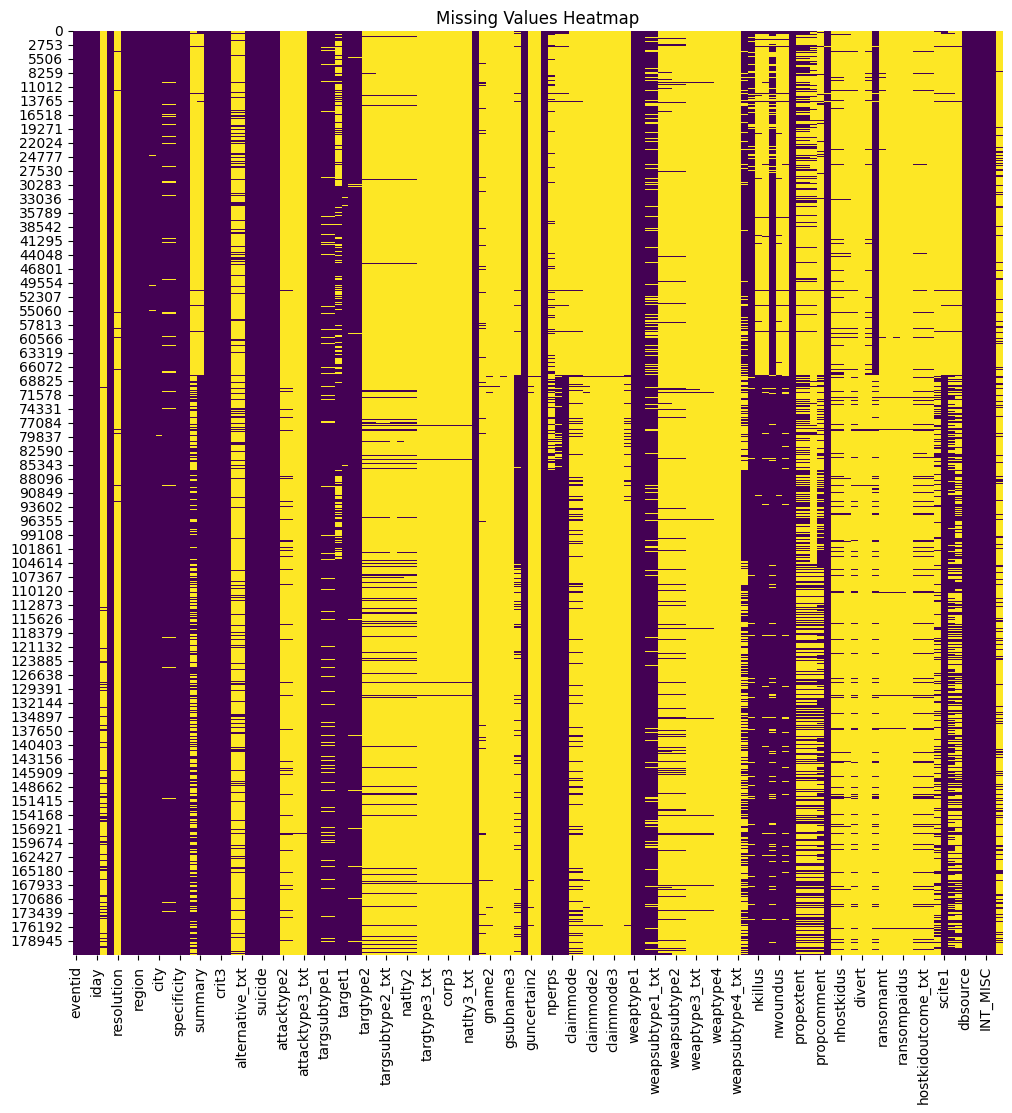

In [112]:
plt.figure(figsize=(12,12))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

<Axes: >

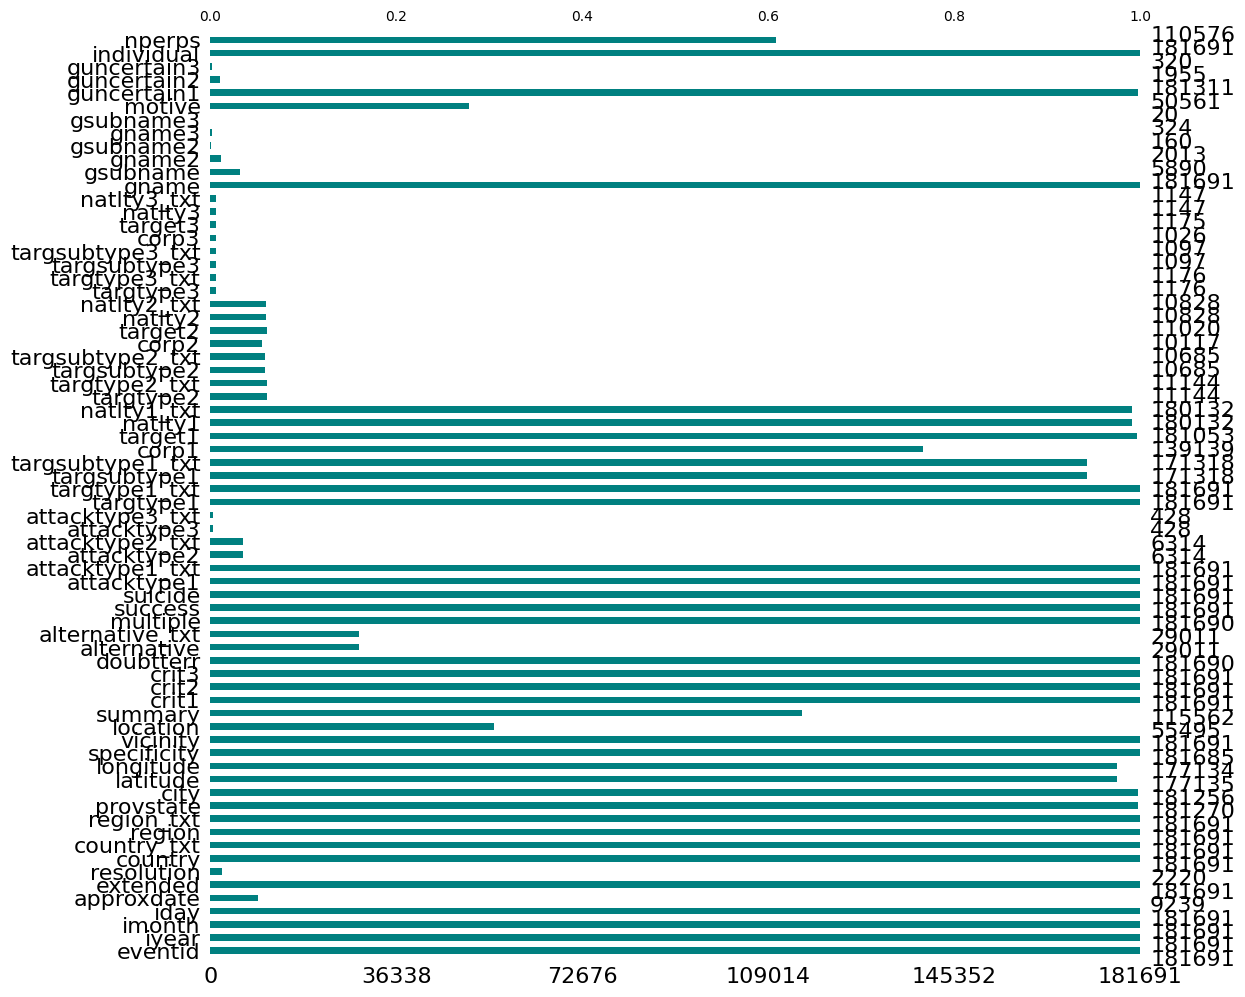

In [113]:
msno.bar(df.iloc[:, :70], color = "teal", figsize=(12,12))

**Dataset Overview**
* Structure & Dimensions - The dataset comprises 112,550 records across 135 features, providing a rich multi-dimensional view of global terrorism incidents. The feature set spans numerical measurements, categorical classifications, and free-text annotations.
## Data Type Distribution

| Type | Columns | Description |
|---|---|---|
| `float64` | 70 | Continuous & encoded numerical features |
| `int64` | 7 | Discrete numerical features |
| `object` | 58 | Categorical & free-text fields |


* Data Integrity
* Duplicate Records: The dataset contains zero duplicate rows, confirming that every entry represents a unique incident. No deduplication is required at this stage.
* Missing Values: A notable challenge in this dataset is the prevalence of null values across multiple columns. Preliminary visualizations — including a missingness heatmap and a column-wise bar chart — reveal two distinct tiers of data completeness:
## Missing Data Summary

| Category | Fields | Recommendation |
|---|---|---|
| **Critically Sparse** (near-entirely null) | `approxdate`, `related`, `scite1`, `scite2`, `scite3` | Exclude or impute based on downstream requirements |
| **Moderately Incomplete** (partial nulls) | `addnotes`, `INT_LOG`, `INT_IDEO`, `INT_MISC`, `INT_ANY` | Mode/median imputation, flag encoding, or conditional dropping |
* Addressing missing values will be a primary focus of the Data Wrangling phase to ensure analytical integrity.



## ***2. Understanding Your Variables***

###**Variables Description**

| Field | Description |
|-------|-------------|
| `iyear` | Year of the incident |
| `imonth` | Month of the incident |
| `iday` | Day of the incident |
| `country_txt` | Country where the incident occurred |
| `region_txt` | World region of the incident |
| `city` | City of the incident |
| `latitude` / `longitude` | GPS coordinates |
| `attacktype1_txt` | Type of attack (e.g., Bombing, Assassination) |
| `targtype1_txt` | Type of target (e.g., Government, Military) |
| `gname` | Name of the terrorist group responsible |
| `weaptype1_txt` | Weapon type used |
| `nkill` | Number of people killed |
| `nwound` | Number of people wounded |
| `success` | Whether the attack succeeded (1 = Yes) |
| `suicide` | Whether it was a suicide attack (1 = Yes) |
| `property` | Property damage (1 = Yes) |


###**Check Unique Values for each variable**

In [114]:
# ── Check unique values for key categorical columns ─────────────────────
key_cat_cols = ['region_txt', 'attacktype1_txt', 'targtype1_txt',
                'weaptype1_txt', 'success', 'suicide']
for col in key_cat_cols:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].value_counts().head(10).to_string())
    print("-" * 60)


region_txt (12 unique values):
region_txt
Middle East & North Africa     50474
South Asia                     44974
South America                  18978
Sub-Saharan Africa             17550
Western Europe                 16639
Southeast Asia                 12485
Central America & Caribbean    10344
Eastern Europe                  5144
North America                   3456
East Asia                        802
------------------------------------------------------------

attacktype1_txt (9 unique values):
attacktype1_txt
Bombing/Explosion                      88255
Armed Assault                          42669
Assassination                          19312
Hostage Taking (Kidnapping)            11158
Facility/Infrastructure Attack         10356
Unknown                                 7276
Unarmed Assault                         1015
Hostage Taking (Barricade Incident)      991
Hijacking                                659
------------------------------------------------------------

targtyp

##***3. DATA WRANGLING***

### **Data Wrangling Code**

In [115]:
df.shape

(181691, 135)

**Removing  & Viewing rows  after removing duplicates**

In [116]:
df = df.drop_duplicates()

In [117]:
print("Rows:", df.shape[0])

Rows: 181691


**Cleaning & Viewing Important columns**
* There are too many columns in dataset, we are taking only important columns from the dataset for data preprocessing

In [118]:
important_cols = [
    'eventid', 'iyear', 'imonth', 'iday',
    'country_txt', 'region_txt', 'provstate', 'city',
    'latitude', 'longitude',
    'success', 'suicide',
    'attacktype1_txt',
    'targtype1_txt', 'targsubtype1_txt',
    'gname',                            # perpetrator group
    'weaptype1_txt',
    'nkill', 'nwound',
    'property', 'propextent_txt',
    'ishostkid',                        # hostage/kidnapping flag
    'ransom',
]
df_clean = df[important_cols].copy()
print(f"Shape : {df_clean.shape}")
df_clean.head()

Shape : (181691, 23)


,eventid,iyear,imonth,iday,country_txt,region_txt,provstate,city,latitude,longitude,...,targtype1_txt,targsubtype1_txt,gname,weaptype1_txt,nkill,nwound,property,propextent_txt,ishostkid,ransom
0,197000000001,1970,7,2,Dominican Republic,Central America & Caribbean,NaN,Santo Domingo,18.456792,-69.951164,...,Private Citizens & Property,Named Civilian,MANO-D,Unknown,1.0,0.0,0,NaN,0.0,0.0
1,197000000002,1970,0,0,Mexico,North America,Federal,Mexico city,19.371887,-99.086624,...,Government (Diplomatic),"Diplomatic Personnel (outside of embassy, cons...",23rd of September Communist League,Unknown,0.0,0.0,0,NaN,1.0,1.0
2,197001000001,1970,1,0,Philippines,Southeast Asia,Tarlac,Unknown,15.478598,120.599741,...,Journalists & Media,Radio Journalist/Staff/Facility,Unknown,Unknown,1.0,0.0,0,NaN,0.0,0.0
3,197001000002,1970,1,0,Greece,Western Europe,Attica,Athens,37.997490,23.762728,...,Government (Diplomatic),Embassy/Consulate,Unknown,Explosives,NaN,NaN,1,NaN,0.0,0.0
4,197001000003,1970,1,0,Japan,East Asia,Fukouka,Fukouka,33.580412,130.396361,...,Government (Diplomatic),Embassy/Consulate,Unknown,Incendiary,NaN,NaN,1,NaN,0.0,0.0


**Converting & Viewing Numeric columns**

In [119]:
num_cols = ['iyear', 'imonth', 'iday', 'nkill', 'nwound', 'success', 'suicide']

for col in num_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

**Filling Missing values**

In [120]:
cat_cols = ['country_txt', 'region_txt', 'city', 'attacktype1_txt', 'targtype1_txt', 'gname', 'weaptype1_txt']

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

for col in ['nkill', 'nwound', 'success', 'suicide', 'iyear', 'imonth', 'iday']:
    df_clean[col] = df_clean[col].fillna(0)


**Data Cleaning — Incorrect Data Types**

A critical step in the data wrangling pipeline is ensuring each column is stored in its correct data type. Misclassified types can produce silent errors in aggregations, visualisations, and model inputs. The following four sub-tasks were performed systematically.

* Checking current data types
An initial audit of all 135 columns was conducted using `df.dtypes` and `df.dtypes.value_counts()` to establish a baseline. This inspection revealed several columns that were incorrectly inferred by pandas at load time — notably numeric fields stored as `object` and date-related fields lacking a proper temporal structure.

* Converting important numeric columns
Key analytical columns — including `nkill`, `nwound`, `latitude`, and `longitude` — were cast to `float64`, while date-part columns (`iyear`, `imonth`, `iday`) were enforced as nullable integers (`Int64`). The conversion was handled using `pd.to_numeric()` with `errors='coerce'` to ensure any non-numeric entries were safely converted to `NaN` rather than raising exceptions.

* Converting text columns to string
All categorical and free-text columns such as `country_txt`, `region_txt`, `attacktype1_txt`, `gname`, and `summary` were explicitly cast to `string` dtype. Leading and trailing whitespace was stripped, and any residual literal `'nan'` strings — an artefact of the type conversion process — were replaced with proper null values to maintain data integrity.

* Cleaning date-related columns
The three date-part columns (`iyear`, `imonth`, `iday`) were combined to construct a unified `date` column of `datetime64` type. Invalid placeholder values (month or day recorded as `0`) were replaced with `NaT` prior to parsing to prevent malformed dates from entering the analysis. The resulting column enables proper time-series operations and temporal filtering across the dataset.


In [121]:
num_cols = [
    'iyear', 'imonth', 'iday', 'country', 'region', 'latitude', 'longitude',
    'specificity', 'vicinity', 'multiple', 'success', 'suicide', 'attacktype1',
    'attacktype2', 'attacktype3', 'targtype1', 'targtype2', 'targtype3',
    'weaptype1', 'weaptype2', 'weaptype3', 'weaptype4', 'nkill', 'nwound',
    'property', 'propextent', 'ransom', 'nperps'
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [122]:
text_cols = [
    'country_txt', 'region_txt', 'provstate', 'city', 'attacktype1_txt',
    'targtype1_txt', 'gname', 'weaptype1_txt', 'gsubname', 'motive'
]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str)

In [123]:
for col in ['iyear', 'imonth', 'iday']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

**Create new columns that will help in further evaluation**

In [124]:
df['casualties'] = df['nkill'].fillna(0) + df['nwound'].fillna(0)
df['year'] = df['iyear']
df['decade'] = (df['iyear'] // 10) * 10
df['month_name'] = pd.to_datetime(df['imonth'], format='%m', errors='coerce').dt.month_name()
df['fatal_attack'] = np.where(df['nkill'].fillna(0) > 0, 'Yes', 'No')

In [125]:
df['country_region'] = df['country_txt'].astype(str) + " - " + df['region_txt'].astype(str)
df['high_casualty'] = np.where(df['casualties'] >= df['casualties'].median(), 'High', 'Low')

### What all manipulations have you done and insights you found?

**DATA MANIPULATIONS**
* Column selection -
The original 135-column dataset was reduced to 14 analytically relevant features — covering temporal identifiers, geography, attack characteristics, perpetrator details, and casualty metrics. Columns with excessive missing values or limited relevance to the core EDA objectives were excluded, resulting in a leaner, more navigable working dataset.
* Handling missing numerical values -
All numeric columns were systematically validated: each was confirmed to exist, coerced to the appropriate numeric dtype, and any non-parseable or invalid entries were replaced with NaN. This ensures downstream aggregations and statistical operations are not distorted by silently corrupt values.
* Handling missing categorical values -
All categorical and free-text columns were explicitly cast to string dtype and standardised. This guarantees consistent behaviour during grouping, filtering, and visualisation operations, and prevents type-related inconsistencies from affecting analysis outcomes.
* Feature engineering -
New derived columns were constructed to enhance analytical utility:
total casualties — sum of nkill and nwound, providing a single composite measure of incident severity.
Additional features were engineered to improve interpretability and support richer visualisation of temporal and geographic trends.
* **KEY INSIGHTS**
1. Simplified data structure - Reducing 135 columns to 14 targeted features significantly improved dataset navigability. The retained columns collectively capture the most critical dimensions of each incident — when, where, how, by whom, and with what impact — without the noise of sparsely populated auxiliary fields.  
2. Data completeness for key metrics - Imputing missing values across critical columns — including nkill, nwound, country_txt, region_txt, attacktype1_txt, and targtype1_txt — ensures these fields can be fully utilised in analysis without introducing bias from row-level data loss.
1.   Direct impact measurement - The engineered total_casualties column consolidates fatalities and injuries into a single, interpretable severity metric. This enables immediate quantification of human impact per incident and supports meaningful trend analysis across regions, attack types, and time periods.




## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

**DATA VISUALIZATION & EXPREIMENTING WITH CHARTS**

In [126]:
df_clean.rename(columns={
    'iyear'           : 'year',
    'imonth'          : 'month',
    'iday'            : 'day',
    'country_txt'     : 'country',
    'region_txt'      : 'region',
    'attacktype1_txt' : 'attack_type',
    'targtype1_txt'   : 'target_type',
    'targsubtype1_txt': 'target_subtype',
    'weaptype1_txt'   : 'weapon_type',
    'propextent_txt'  : 'property_extent',
    'nkill'           : 'killed',
    'nwound'          : 'wounded',
}, inplace=True)

df_clean['decade'] = (df_clean['year'] // 10) * 10
df_clean['decade_label'] = df_clean['decade'].astype(str) + 's'
df_clean['total_casualties'] = df_clean['killed'] + df_clean['wounded']

print(list(df_clean.columns))

['eventid', 'year', 'month', 'day', 'country', 'region', 'provstate', 'city', 'latitude', 'longitude', 'success', 'suicide', 'attack_type', 'target_type', 'target_subtype', 'gname', 'weapon_type', 'killed', 'wounded', 'property', 'property_extent', 'ishostkid', 'ransom', 'decade', 'decade_label', 'total_casualties']


###**Univariate Analysis**

####**Chart - 1: Number of Terrorist Attacks Each Year**

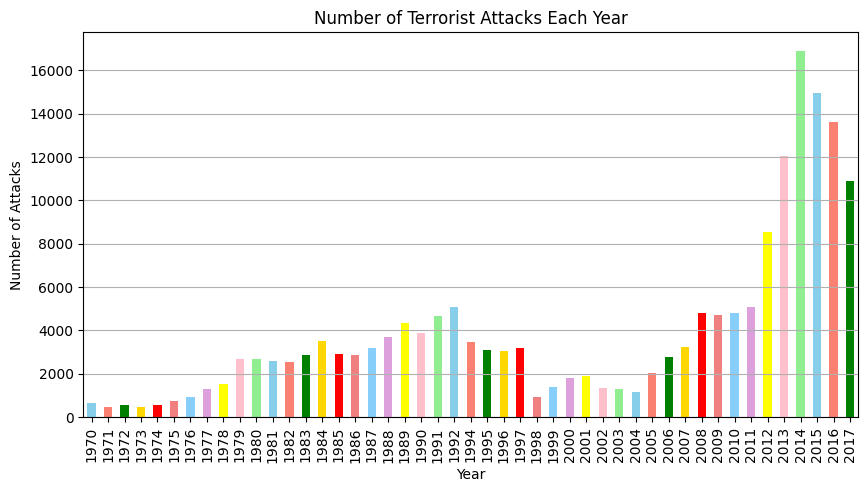

In [127]:
attacks_per_year = df['year'].value_counts().sort_index()
plt.figure(figsize=(10, 5))
colors = ['skyblue', 'salmon', 'green', 'gold', 'red', 'lightcoral', 'lightskyblue', 'plum', 'yellow', 'pink', 'lightgreen']
attacks_per_year.plot(kind='bar', color=colors)
plt.title('Number of Terrorist Attacks Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.grid(axis='y')
plt.show()


1. **Why did you pick the specific chart?**

   I chose a bar chart for this visualization because it's highly effective for displaying the frequency of events (number of attacks) across discrete categories (years). Each bar clearly represents the total number of attacks in a given year, making it easy to compare attack counts across different years and identify trends over time.
* **The chart reveals five distinct phases in global terrorism activity:**
* 1970 – late 1970s - (~600 → ~2,700)
A steady early rise from minimal baseline activity, accelerating sharply toward 1980.
* 1980 – early 1990s - (~2,500 – ~5,100)
Sustained elevated activity with a notable peak around 1992, driven by geopolitical conflicts across multiple regions.
* Mid-1990s – early 2000s - (~1,000 – ~3,200)
A marked trough bottoming near 1998, followed by subdued recovery — the lowest sustained period in the dataset.
* 2004 – 2011 - (~1,200 → ~5,000)
A renewed and accelerating uptrend, reflecting growing instability across the Middle East, South Asia, and Sub-Saharan Africa
* 2011 – 2017  |  Peak: 2014 - (~5,000 → 16,903 → ~10,900)
An unprecedented surge driven by the rise of ISIL and ongoing conflicts in Iraq, Syria, Afghanistan, and Nigeria. The 2014 peak represents the highest single-year count in the entire dataset. Although activity declined post-2014, volumes remained far above any pre-2012 level, indicating a persistently elevated global threat baseline.


**Business Impact**
* **Positive impact (Strategic opportunities enabled by these insights)** -


1.   Security optimisation - Temporal trend data enables governments and security firms to anticipate high-risk periods and allocate resources proactively, reducing exposure and operational losses.
2.   Informed policy making - Clear escalation signals support the design of targeted counter-terrorism policies and international cooperation frameworks, fostering global stability conducive to trade and investment.
1.   Risk modelling - Insurance, logistics, and tourism sectors can leverage historical frequency data for more accurate risk pricing, route planning, and safety protocol development.
2.   Humanitarian planning - Escalation patterns allow NGOs and aid organisations to pre-position resources in regions approaching crisis thresholds before conditions deteriorate further.

* **Negative growth (Risks indicated by the sustained post-2011 escalation)**


1.   Rising operational costs - Businesses in high-risk regions face elevated security expenditure, higher insurance premiums, and increasing operational complexity — directly compressing margins.
2.   Supply chain disruption - Attacks on transportation corridors introduce delays, cost overruns, and revenue loss for businesses reliant on globally integrated supply chains.
1.   Deterred investment & tourism - Sustained instability suppresses foreign direct investment and visitor arrivals, stalling economic development in the most affected regions
2.   Human capital erosion - Casualties and psychological trauma diminish workforce productivity, increase attrition, and impose long-term costs on organisational resilience.






####**Chart - 2: Showing number of attacks by year**

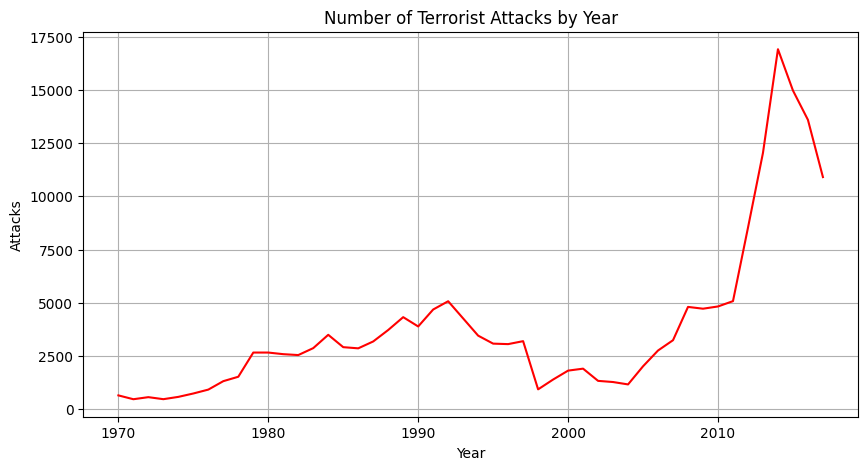

In [128]:
yearly_attacks = df.groupby('year')['eventid'].count()
plt.figure(figsize=(10,5))
yearly_attacks.plot(kind='line', color='red')
plt.title('Number of Terrorist Attacks by Year')
plt.xlabel('Year')
plt.ylabel('Attacks')
plt.grid(True)
plt.show()


1. **Why did you pick the specific chart?**

   I chose a line chart for visualizing the 'Trend of Terrorist Attacks Over Time' because it is exceptionally good at displaying changes and patterns of a quantitative variable (number of attacks) over a continuous period (years). The line connects data points chronologically, making it easy to observe increases, decreases, and overall trends, which is crucial for understanding the evolution of terrorist activity throughout the years.
* **Six distinct phases define the global terrorism trajectory:**
* 1970s – 1980s-
Moderate and fluctuating activity with incremental growth — a period of relatively contained, regionally concentrated terrorism.
* Late 1980s – early 1990s -
A pronounced surge in attack frequency, reflecting escalating geopolitical conflicts across multiple theatres, followed by a brief pullback.
* Mid-1990s – early 2000s -
A sustained trough — the calmest sustained period in the dataset — as several regional conflicts de-escalated and international counter-terrorism frameworks matured.
* Post-2004 -
A decisive and accelerating inflection point, marking the onset of a new era of global terrorism driven by ideologically motivated non-state actors.
* 2014 — peak year -
The single highest annual count in the dataset — a convergence of ISIL expansion, ongoing conflicts in Iraq, Syria, Afghanistan, and Nigeria.
* 2015 – 2017 - A modest decline from peak levels, yet volumes remain far above any pre-2012 precedent — confirming a structurally elevated global threat baseline rather than a cyclical correction.



**Business Impact**
* **Positive impact (Strategic opportunities enabled by trend intelligence)** -


1.   Strategic risk management - Identifying escalation phases enables multinationals and financial institutions to proactively rebalance investment portfolios, harden supply chains, and redeploy personnel ahead of deteriorating conditions.
2.   Security sector growth - Rising threat trajectories drive demand for advanced security technologies, intelligence services, and counter-terrorism capabilities — creating significant commercial opportunity for defence and cybersecurity firms.
1.   Insurance & actuarial refinement - Temporal trend data allows insurers to recalibrate terrorism risk models, enabling more accurate premium pricing and development of targeted coverage products for volatile operating environments.
2.   Humanitarian pre-positioning - NGOs can leverage escalation signals to deploy aid, medical supplies, and emergency response capacity to at-risk regions before crises peak, improving response effectiveness.

* **Negative growth (Economic consequences of the post-2004 escalation)**


1.   Investment uncertainty - Persistent instability makes long-term planning difficult, leading to deferred investment decisions, capital flight, and reduced appetite for expansion into affected markets.
2.   Elevated operational costs - Security expenditure — guards, surveillance, hardened facilities, executive protection — diverts capital from productive investment in R&D and market development, eroding margins.
1.   Supply chain & market disruption - Higher attack frequency directly correlates with infrastructure damage, logistics delays, and restricted market access — raising costs and compressing revenue across globally integrated supply chains.
2.  Deterred FDI & tourism - Regions experiencing sustained escalation are perceived as structurally unsafe, actively deterring foreign direct investment and tourism — two primary engines of economic development in emerging markets.





####**Chart - 3: Distribution of Attack Types**

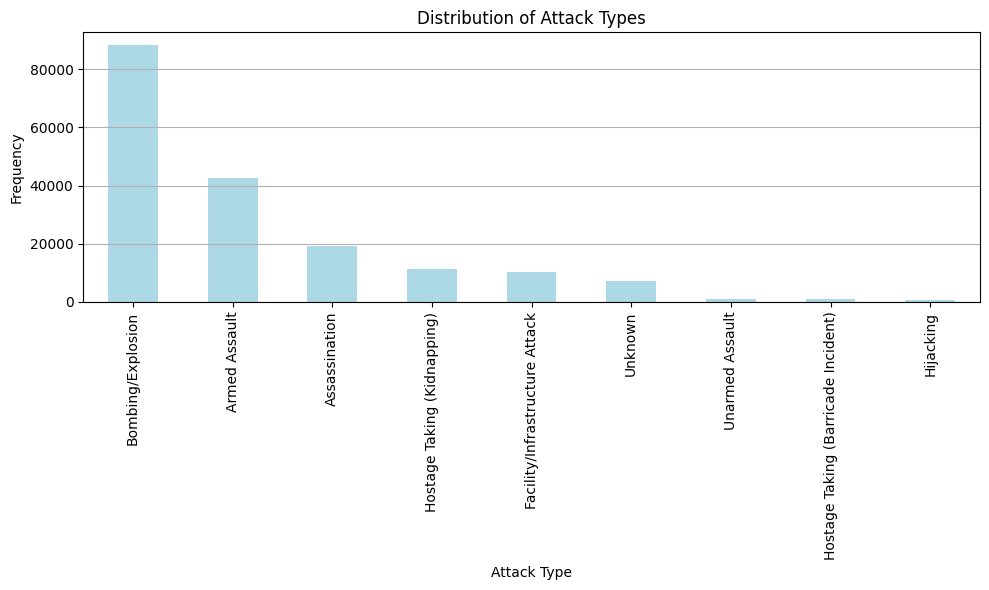

In [129]:
attack_type_counts = df['attacktype1_txt'].value_counts()
plt.figure(figsize=(10, 6))
attack_type_counts.plot(kind='bar', color='lightblue')
plt.title('Distribution of Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


1. **Why did you pick the specific chart?**

     I chose a bar chart to display the 'Distribution of Attack Types' because it is an excellent choice for visualizing the frequency or count of categorical data. Each bar clearly represents a distinct attack type, and its height directly corresponds to the number of occurrences for that type. This makes it very easy to compare the prevalence of different attack methods at a glance, allowing for quick identification of the most common and least common attack types.
* **Distribution of attack types(Attack types stratify naturally into three frequency tiers:)**
* Dominant (Bombing / Explosion) -
Overwhelmingly the most prevalent method — accounting for nearly half of all recorded incidents. The preferred tool due to its scalability, anonymity, and mass-casualty potential.
* High frequency (Armed Assault) -
A clear second — substantially less common than bombings but far ahead of other methods. Indicates a strong preference for direct, confrontational violence.
* Moderate (Assassination & Kidnapping) -
The next tier reflects a strategic dimension — targeted elimination and hostage-taking for leverage, ransom, or political coercion.
* Notable (Facility / Infrastructure attack) -
A meaningful share of incidents target physical infrastructure — signalling intent to disrupt essential services, economies, or state symbols.
* Rare (Unarmed assault, barricade incidents & hijacking) - The least common methods — reflecting either high operational complexity (hijacking), limited lethality incentive (unarmed assault), or tactical specificity (barricade incidents) that constrains their adoption by most groups.




**Business Impact**
* **Positive impact (Strategic value of knowing the attack method landscape)** -


1.   Targeted security investment - The clear dominance of bombings and armed assaults enables security agencies and corporations to concentrate resources on detection, hardening, and rapid-response protocols for these specific methods — improving ROI on security spend.
2.   Security technology R&D - Frequency data creates a prioritised product roadmap for security firms — driving investment in explosive detection systems, perimeter barriers, and assault prevention tools where market demand is highest.
1.   Infrastructure resilience planning - The notable prevalence of facility attacks gives critical infrastructure operators — energy, transport, communications — a clear mandate to design targeted resilience frameworks and reduce operational downtime risk.
2.   Emergency preparedness - Knowing the predominant attack types allows healthcare providers and emergency services to pre-configure trauma response capacity and casualty management protocols for the most likely scenarios.

* **Negative growth (Economic consequences of high-prevalence destructive methods)**


1. Physical & economic damage - Bombings and armed assaults cause direct destruction of property, infrastructure, and productive assets — generating reconstruction costs, asset write-offs, and GDP contraction in affected areas.
2.   Human capital loss - High-casualty attack types deplete skilled labour, suppress consumer confidence, and impose lasting healthcare burdens — compounding economic damage well beyond the immediate incident.
1.   Business & commerce disruption - Repeated attacks force temporary or permanent business closures, interrupt supply chains, and create an atmosphere of chronic instability that actively deters commerce, tourism, and new market entry.
2.  Misallocated capital - Mandatory security spending diverts funds from productive investment — R&D, capacity expansion, workforce development — indirectly constraining long-term growth potential for both businesses and governments.




####**Chart - 4: Bar chart showing top 10 countries with most attacks**

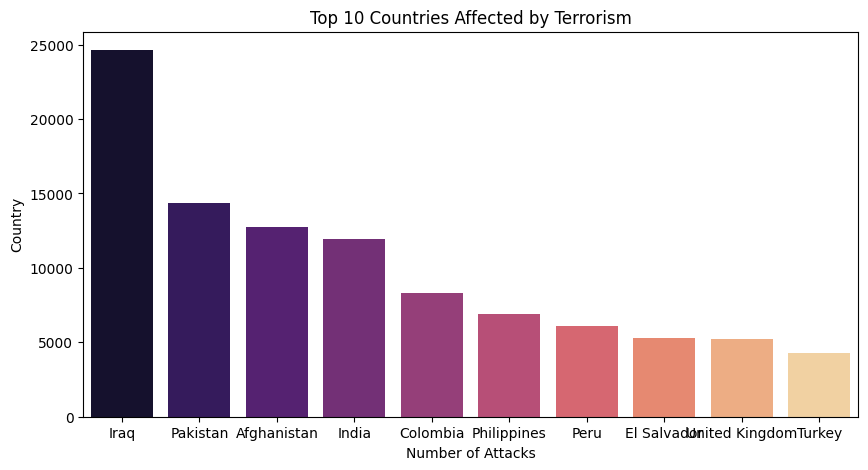

In [130]:
top_countries = df['country_txt'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.index, y=top_countries.values,
            hue=top_countries.index, palette='magma', legend=False)
plt.title('Top 10 Countries Affected by Terrorism')
plt.xlabel('Number of Attacks')
plt.ylabel('Country')
plt.show()


1. **Why did you pick the specific chart?**

   I selected a bar chart to visualize the 'Number of Terrorist Attacks by Country (Top 15)' because it is highly effective for comparing the magnitude of a single variable (number of attacks) across distinct, categorical entities (countries). By arranging the countries in descending order of attack counts, it clearly highlights the top 15 most affected nations, making it easy to identify which countries bear the brunt of terrorist activities. This direct comparison is visually intuitive and allows for quick insights into geographical hotspots.
* **Number of terrorist attacks by country — top 15(Four geographic patterns define the distribution:)**
* Apex concentration (Iraq stands alone at the top) - Iraq records a substantially higher attack count than any other nation in the dataset — reflecting the compounded effect of prolonged state fragility, sectarian conflict, and ISIL's territorial expansion in the 2010s.
* Middle East & South Asia (Regional dominance) - Pakistan, Afghanistan, and India consistently rank among the top positions, confirming that the Middle East and South Asia bear a disproportionate share of the global terrorism burden.
* Latin America (Colombia as an outlier) - Colombia's presence in the top 15 underscores that terrorism is not geographically exclusive to conflict-zone regions — insurgent and narco-terrorism have generated sustained high-frequency activity in South America as well.
* Burden distribution (Disproportionate concentration) - A small cluster of nations at the top of the ranking collectively accounts for a large majority of all recorded incidents globally — a classic heavy-tail distribution that signals deep, structural drivers of terrorism rather than diffuse, opportunistic activity.


**Business Impact**
* **Positive impact (Strategic value of geographic concentration data)** -


1.   Geographic risk prioritisation - Country-level rankings allow corporations, insurers, and governments to tier their risk exposure and concentrate security investment and contingency planning in the highest-impact jurisdictions.
2.   Market entry intelligence - Businesses evaluating expansion into emerging markets can use this data to benchmark country risk, adjust entry strategies, and structure operations with appropriate security infrastructure from the outset.

* **Negative growth (Structural consequences of chronic high-frequency attack nations)**


1. Deterred investment & capital flight - Chronic instability in top-ranked countries drives both foreign and domestic capital away — stifling business development, employment creation, and long-term economic expansion.
2.  Infrastructure damage & reconstruction burden - High attack volumes — dominated by bombings — generate recurring costs for repairing public infrastructure and private assets, diverting government resources from productive investment.
1.   Human capital erosion - Sustained high casualty rates deplete skilled workforces, overwhelm healthcare systems, and trigger mass displacement — compressing economic output and long-term development potential.
2.  Trade, tourism & social fragmentation - Persistent insecurity disrupts trade corridors, eliminates tourism revenue, and drives refugee crises — imposing spillover economic burdens on neighbouring countries and undermining regional stability.




####**Chart - 5: Pie chart showing target types**

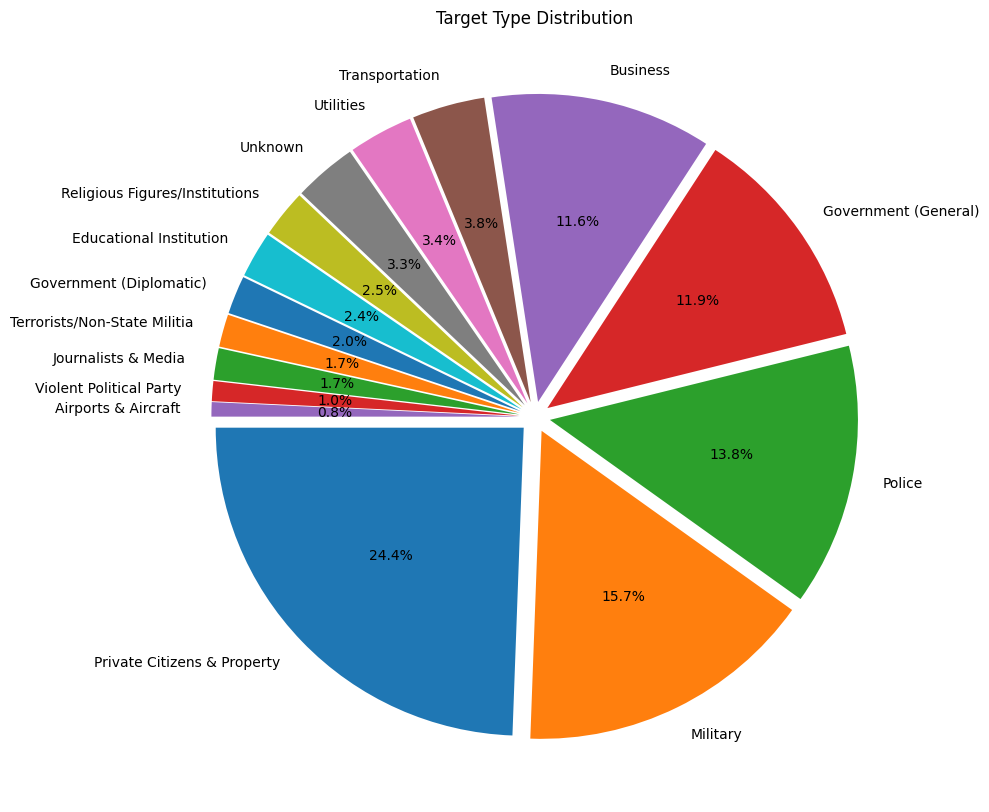

In [131]:
target_types = df['targtype1_txt'].value_counts().head(15)
plt.figure(figsize=(10,10))
plt.pie(target_types.values, labels=target_types.index, explode=[0.05]*len(target_types), autopct='%1.1f%%', startangle=180)
plt.title('Target Type Distribution')
plt.show()


1. **Why did you pick the specific chart?**

     I chose a pie chart to visualize the 'Distribution of Target Types in Terrorist Attacks' because it is highly effective for displaying the percentage count of distinct categorical variables. Each sector clearly represents a different target type, and its height immediately conveys the number of times that target type has been attacked. This allows for easy comparison of the prevalence of various targets, making it simple to identify which categories are most frequently targeted by terrorist activities.
* **Distribution of target types in terrorist attacks(Target types stratify into three clear frequency tiers:)**
* Primary target (Private citizens & property) - The single largest target category — reflecting a deliberate strategy to maximise civilian fear, casualties, and psychological impact on the general population.
* High frequency (Military, police & government) - State security apparatus and governance structures are the next most targeted — indicating direct ideological confrontation with state authority and attempts to erode institutional legitimacy.
* Significant (Business sector) - Commercial targets are frequently attacked to disrupt economic activity, deter investment, and undermine public confidence in the stability of markets.
* Notable (Transport, utilities & infrastructure) - Attacks on critical services aim to generate cascading disruption — affecting entire economies and populations far beyond the point of attack.
* Moderate (Education & religious institutions) - Targeting these sectors signals an intent to fracture social cohesion, suppress ideology, or intimidate specific community and faith groups.
* Least frequent (Diplomatic, NGOs & non-state actors) - The least targeted categories — though their lower frequency does not diminish the strategic significance of attacks when they do occur



**Business Impact**
* **Positive impact (Value of target-type intelligence for stakeholders)** -


1.   Prioritised security investment - Knowing which sectors are most frequently targeted enables businesses and governments to concentrate protective measures where risk is highest — improving security ROI and reducing exposure for commercial centres, public spaces, and government facilities
2.   Refined insurance risk modelling - Insurers can design more precise, sector-specific terrorism policies by aligning premium structures with empirical target frequency data — offering businesses clearer financial risk transfer mechanisms.
1.   Security product innovation - Target distribution data creates a prioritised development roadmap for security technology firms — directing R&D toward surveillance, infrastructure hardening, and personnel protection for the most vulnerable categories.
2.   Policy & advocacy alignment - Sector-specific targeting patterns inform public policy and business advocacy efforts, enabling more targeted legislative and regulatory frameworks to protect the most at-risk entities.



* **Negative growth (Economic consequences of the target landscape)**


1. Direct asset & revenue losses - Attacks on private citizens, property, and businesses destroy physical assets, reduce consumer activity, and interrupt operations — translating directly into profit erosion, job losses, and GDP contraction.
2.  Investor confidence erosion - Frequent targeting of economic and civilian sectors signals systemic instability, deterring foreign direct investment and capital deployment — compounding long-term growth constraints.
1.   Critical service disruption - Attacks on transportation, utilities, and government infrastructure produce cascading failures across dependent sectors — amplifying economic damage well beyond the immediate point of impact.
2.  Social & human capital costs - Civilian-focused attacks generate casualties, mass displacement, and chronic fear — depleting workforce capacity, suppressing consumer confidence, and imposing long-term public health and productivity burdens.



###**Bivariate Analysis**

####**Chart - 6: Comparison of People Wounded and Killed**

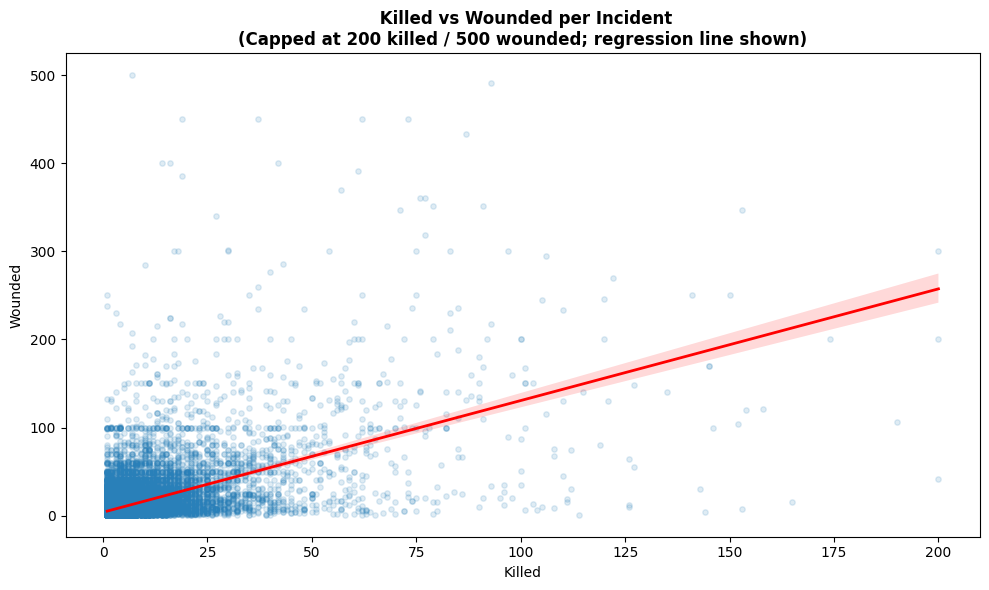

In [132]:
scatter_df = df[(df['nkill'] > 0) & (df['nwound'] > 0) &
                (df['nkill'] <= 200) & (df['nwound'] <= 500)]

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=scatter_df, x='nkill', y='nwound',
            scatter_kws={'alpha': 0.15, 's': 15, 'color': '#2980b9'},
            line_kws={'color': 'red', 'linewidth': 2}, ax=ax)
ax.set_title(f" Killed vs Wounded per Incident\n"
             f"(Capped at 200 killed / 500 wounded; regression line shown)",
             fontweight="bold")
ax.set_xlabel("Killed")
ax.set_ylabel("Wounded")
plt.tight_layout()
plt.show()

* **Why a scatter plot with regression line?** -
A scatter plot is the most appropriate chart for examining the relationship between two continuous variables — fatalities and injuries per incident. Each data point represents a single attack, allowing the distribution, density, and outliers of the killed-wounded relationship to be observed simultaneously. The overlaid regression line quantifies the directional trend across the dataset, while the shaded confidence band communicates the statistical reliability of that estimate — a level of analytical rigour not achievable with categorical chart types. Capping at 200 killed / 500 wounded preserves visual clarity without discarding the structural patterns in the bulk of the data.
* **Killed vs Wounded per Incident(Five key patterns emerge from the scatter plot:)**
* Dominant — 50.9% (Explosives) -
The single most prevalent weapon — used in over half of all recorded attacks. Their scalability, range, and capacity for mass casualties make them the weapon of choice across virtually all terrorist typologies.
* High frequency — 32.2% (Firearms) - The second dominant category — widely accessible and operationally flexible, firearms are the primary tool for armed assaults, targeted killings, and direct engagements with security forces.
* Notable — 8.3% (Unknown) - A non-trivial share where weapon type could not be determined — reflecting data gaps in incident reporting, particularly for older records or incidents in remote areas.
* Moderate — 6.1% (Incendiary) - Fire-based weapons represent a meaningful minority — favoured for their ability to cause destruction and psychological impact with relatively simple execution.
* Rare — 2.0% (Melee) -
Low-frequency but non-negligible — typically associated with opportunistic or low-resource attacks where access to conventional weapons is constrained.
* Minimal — 0.4% (Other) - A residual category covering unconventional or unclassified methods — statistically negligible but worth monitoring for emerging threat vectors.



**Business Impact**
* **Positive impact (Analytical value of the casualty relationship)** -


1.   Casualty forecasting & preparedness - The positive correlation enables healthcare systems and emergency responders to use fatality estimates as a proxy for expected injury volume — improving pre-deployment of medical resources, triage capacity, and trauma care logistics before full incident data is available.
2.   Insurance severity modelling - The kill-wound relationship provides actuaries with a quantitative basis for modelling total casualty exposure per incident — supporting more accurate pricing of terrorism life, health, and liability insurance products.
1.   Security infrastructure design - The outlier pattern — high wounded at low killed — identifies blast-type incidents in dense environments as disproportionately injurious. This directs investment toward blast mitigation, crowd-space hardening, and rapid evacuation infrastructure where injury reduction potential is highest.
2.   Humanitarian resource allocation - Understanding that most incidents are low-casualty but a small number generate extreme totals allows NGOs to maintain scalable response frameworks — calibrated to the typical case but capable of rapid surge for mass-casualty events.

* **Negative growth (Economic and human consequences of the casualty relationship)**


1. Compounded healthcare burden - The positive kill-wound correlation means high-fatality attacks simultaneously generate large numbers of injured survivors — placing acute and sustained pressure on healthcare infrastructure, public health budgets, and long-term rehabilitation systems.
2.  Amplified human capital loss - Mass-casualty events deplete both the deceased and the wounded from the productive workforce — the injured often face prolonged recovery, disability, or psychological trauma that reduces long-term economic output well beyond immediate mortality figures.
1.  Disproportionate impact of outlier events - The extreme outlier incidents — where hundreds are wounded — cause sudden, severe disruptions to local economies, supply chains, and public confidence that can persist for months or years after the attack itself.
2.  Rising insurance & liability costs - The wide variance in casualty outcomes — even for similar fatality counts — makes risk exposure difficult to bound, driving up insurance premiums and increasing contingent liability provisions for businesses operating in high-risk environments.


####**Chart - 7: Comparison of People Wounded and Killed in Top 15 Affected Countries**

<Figure size 1200x600 with 0 Axes>

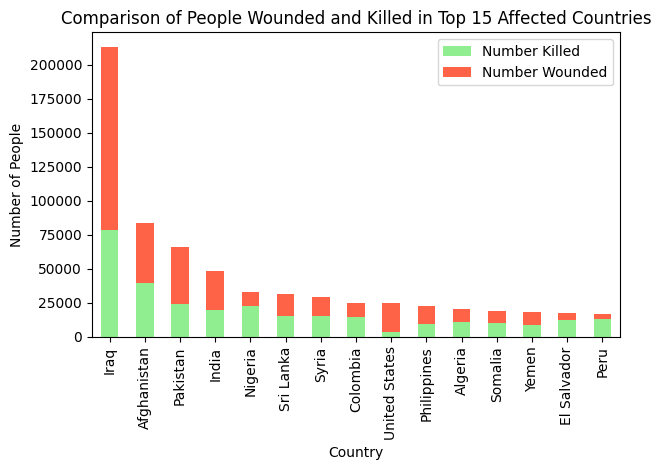

In [133]:
country_casualties = df.groupby('country_txt')[['nkill', 'nwound']].sum()

country_casualties['total_casualties'] = country_casualties['nkill'] + country_casualties['nwound']
country_casualties = country_casualties.sort_values(by='total_casualties', ascending=False).head(15)

plt.figure(figsize=(12, 6))
country_casualties[['nkill', 'nwound']].plot(kind='bar', stacked=True, color=['lightgreen', 'tomato'])
plt.title('Comparison of People Wounded and Killed in Top 15 Affected Countries')
plt.xlabel('Country')
plt.ylabel('Number of People')
plt.xticks(rotation=90)
plt.legend(['Number Killed', 'Number Wounded'])
plt.tight_layout()
plt.show()


1. Why did you pick the specific chart?
 * Comparison of Multiple Metrics: It effectively allows for the comparison of two related quantitative metrics ('Killed' and 'Wounded') for each country simultaneously.
  * Total Impact per Country: By stacking the bars, it clearly shows the total human impact (killed + wounded) for each country, which is the primary sorting criterion for the top 15 countries. This provides an immediate understanding of which countries suffer the most overall casualties.
  * Proportional Contribution: Within each country's bar, the stacked segments illustrate the proportion of killed versus wounded. This helps in discerning if a country experiences predominantly fatalities or injuries.
  * Identification of Hotspots and Severity: It makes it easy to identify the countries with the highest overall casualties and to visually assess the severity distribution within those casualties across the top affected nations.
  * Clear Categorical Comparison: Like a standard bar chart, it's excellent for comparing discrete categories (countries) against each other.

From the 'Comparison of People Wounded and Killed in Top 15 Affected Countries' chart, we can deduce the following insights:

  * Iraq Leads in Casualties: Iraq stands out significantly with the highest total casualties (both killed and wounded), far exceeding any other country, reinforcing its position as the most impacted nation.
  * Concentration of High Casualties: Similar to the total attack count, a few countries, primarily in the Middle East and South Asia (e.g., Afghanistan, Pakistan), account for a disproportionately large share of total casualties.
  * Wounded Often Exceed Killed: In many of the top affected countries, the number of wounded victims is substantially higher than the number of fatalities (e.g., Iraq, Pakistan, Syria, Nigeria, Afghanistan). This indicates a high frequency of attacks that cause injuries without always being immediately fatal, or tactics designed to incapacitate rather than kill.
  * Varied Fatality Ratios: While wounded generally exceed killed, some countries show a relatively higher proportion of killed compared to wounded (e.g., El Salvador, Peru, Algeria). This might suggest differences in attack lethality, medical response, or the types of incidents prevalent in those regions.
  * Emerging Hotspots in Africa: Countries like Nigeria and Somalia appear among the top affected in terms of casualties, highlighting significant human impact in Sub-Saharan Africa due to terrorism.
  * Overall Severity: The chart underscores the severe human cost of terrorism, with tens of thousands killed and hundreds of thousands wounded in the most affected nations, reflecting extensive suffering and public health burdens.


Business Impact

  Positive Impact (through informed mitigation):

  * Strategic Resource Allocation for Security and Aid: The clear identification of countries with the highest overall casualties (e.g., Iraq, Afghanistan, Pakistan) allows governments, international organizations, and private security firms to concentrate resources and aid effectively. This includes deploying specialized medical teams, counter-terrorism units, and humanitarian assistance to where it is most critically needed, potentially saving lives and reducing long-term instability. Companies operating in these regions can prioritize investment in localized security and emergency response infrastructure.
  * Tailored Risk Assessment and Insurance Products: Insurers and reinsurers can use this granular country-level data on casualties to develop more precise risk models. This enables them to offer tailored insurance products and risk management consulting for businesses and individuals operating in these high-risk areas, allowing for better financial planning and risk transfer.
  * Humanitarian Technology and Innovation: The data can spur innovation in humanitarian technology, such as rapid deployment medical solutions, trauma care advancements, and technologies for civilian protection in conflict zones. Companies developing these solutions can find market opportunities rooted in addressing these severe human impacts.

  Negative Growth:

  * Catastrophic Human Capital Loss: The sheer number of killed and wounded in these countries represents an immense depletion of human capital. This directly impacts the workforce, reduces productivity, and creates significant social burdens from long-term care for the injured and displaced. Economic recovery and development are severely hampered when a large portion of the population is either lost or incapacitated.
  * Severe Economic Disruption and Investment Deterrence: Countries with such high casualty rates are perceived as extremely high-risk. This deters foreign direct investment, leads to capital flight, and stifles local business growth. Infrastructure is destroyed, trade routes are disrupted, and tourism collapses, creating a cycle of poverty and underdevelopment. Businesses face exorbitant operating costs due to security needs and uncertainty.
  * Forced Migration and Brain Drain: Persistent high casualties often lead to widespread internal displacement and cross-border migration. This results in 'brain drain' as skilled individuals and educated professionals flee, further diminishing the human capital necessary for national recovery and development.


####**Chart - 8: Bar chart for showing most common attack types**

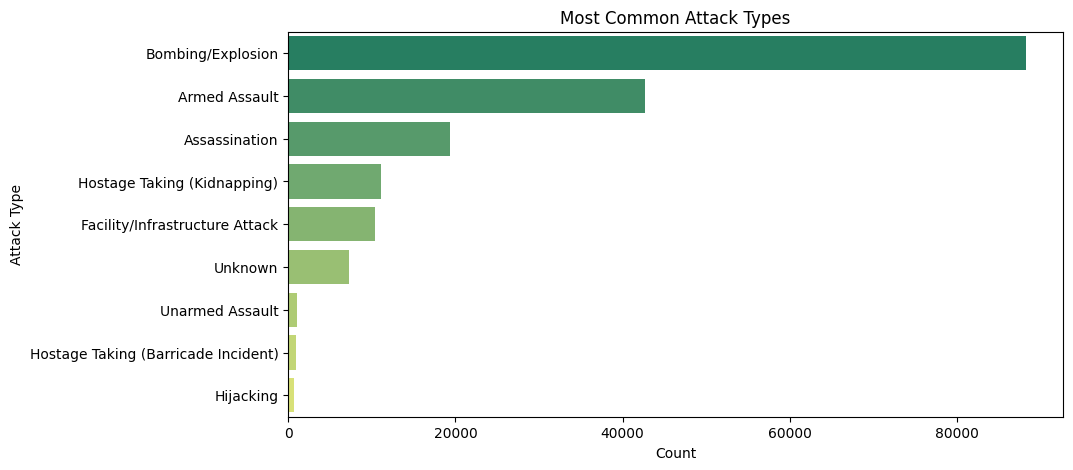

In [134]:
attack_types = df['attacktype1_txt'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=attack_types.values, y=attack_types.index,
            hue=attack_types.index, palette='summer', legend=False)
plt.title('Most Common Attack Types')
plt.xlabel('Count')
plt.ylabel('Attack Type')
plt.show()

####**Chart - 9: Histogram showing casualties distribution**

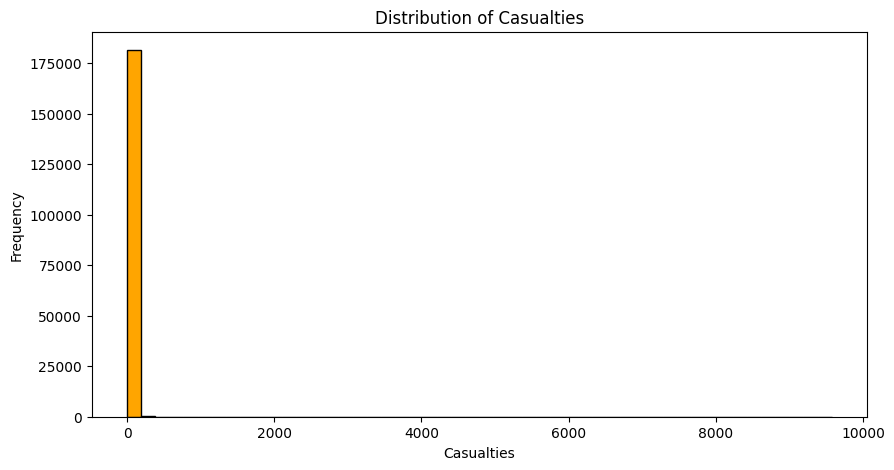

In [135]:
plt.figure(figsize=(10,5))
plt.hist(df['casualties'].fillna(0), bins=50, color='orange', edgecolor='black')
plt.title('Distribution of Casualties')
plt.xlabel('Casualties')
plt.ylabel('Frequency')
plt.show()

####**Chart - 10: Box plot showing outliers in casualties**

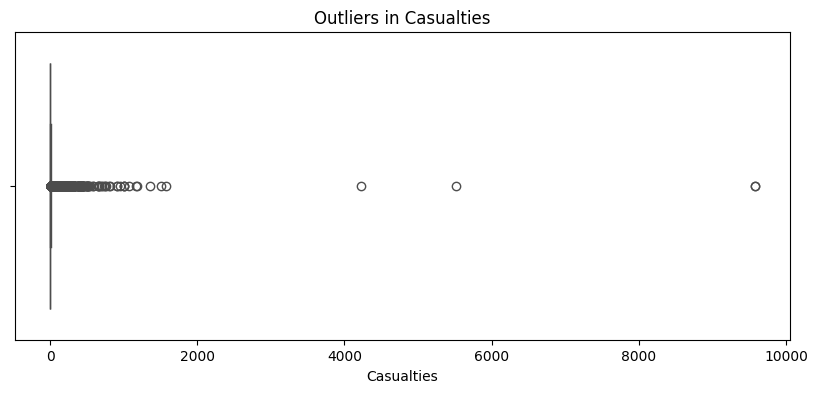

In [136]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['casualties'], color='blue')
plt.title('Outliers in Casualties')
plt.xlabel('Casualties')
plt.show()

###**Multivariate Analysis**

####**Chart - 11: Proportion of Attacks by Region Over Time (Stacked Area)**

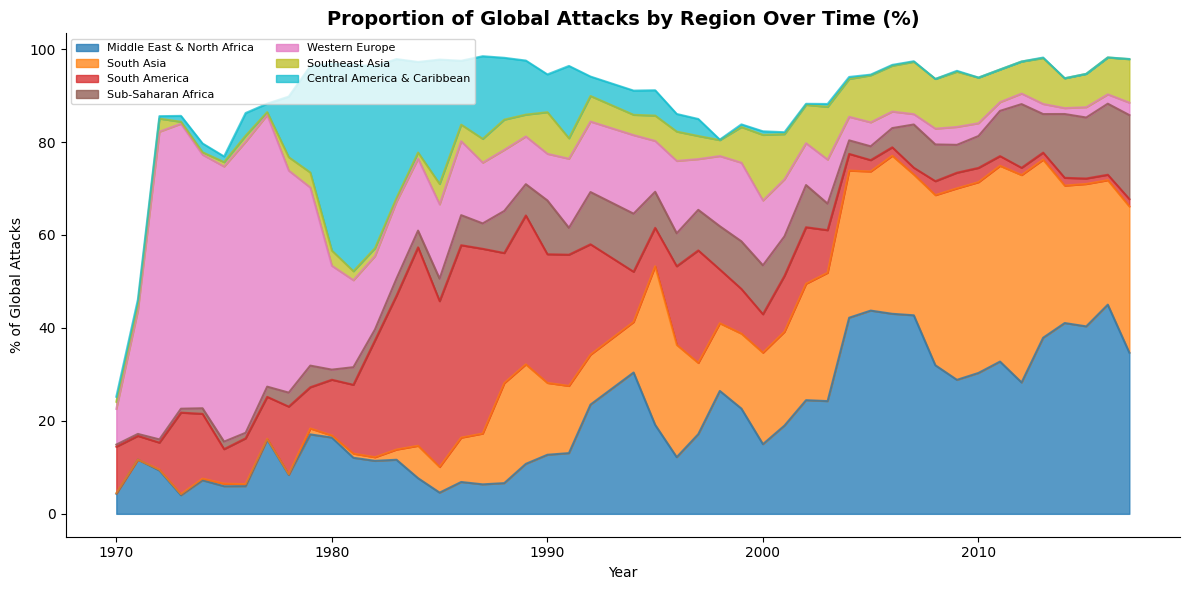

In [137]:
region_year = (df_clean.groupby(['year', 'region']).size()
               .unstack(fill_value=0))
region_year_pct = region_year.div(region_year.sum(axis=1), axis=0) * 100

# Select top 7 regions for clarity
top_regions = df_clean['region'].value_counts().head(7).index
region_year_pct = region_year_pct[top_regions]

fig, ax = plt.subplots(figsize=(12, 6))
region_year_pct.plot(kind='area', stacked=True, ax=ax,
                     colormap='tab10', alpha=0.75)
ax.set_title('Proportion of Global Attacks by Region Over Time (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('% of Global Attacks')
ax.legend(loc='upper left', fontsize=8, ncol=2)
sns.despine()
plt.tight_layout()
plt.show()

####**Chart - 12: Attacks by Region and Decade (Heatmap)**

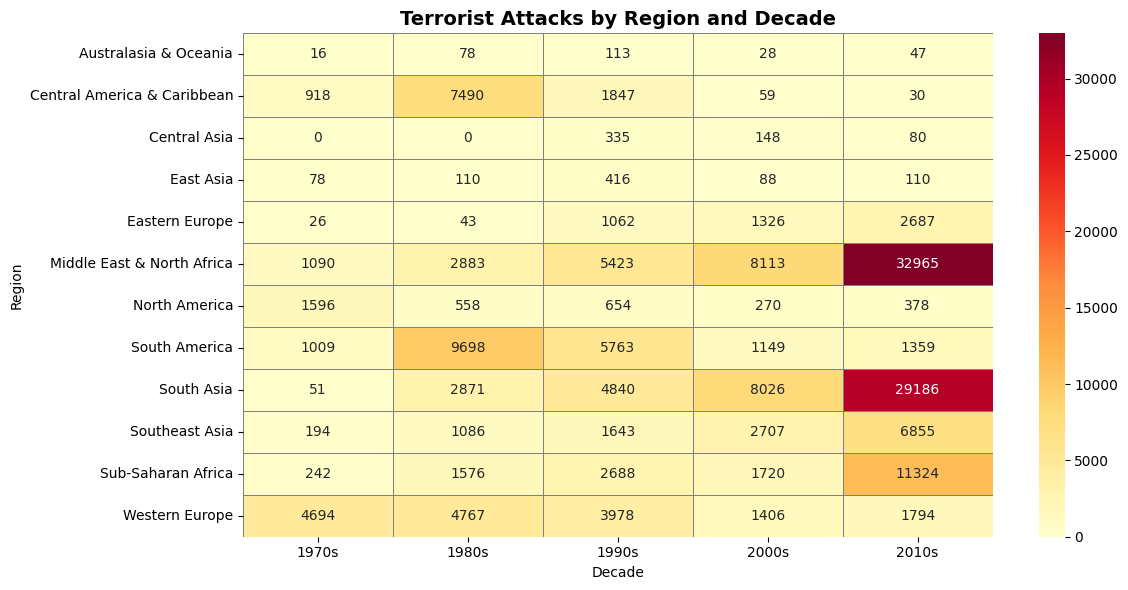

In [138]:
region_decade = df_clean.groupby(['region', 'decade_label']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(region_decade, cmap='YlOrRd', annot=True, fmt='d',
            linewidths=0.5, linecolor='grey')
plt.title('Terrorist Attacks by Region and Decade', fontsize=14, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

####**Chart - 13: Lethality vs. Attack Frequency for Top Groups (Scatter)**

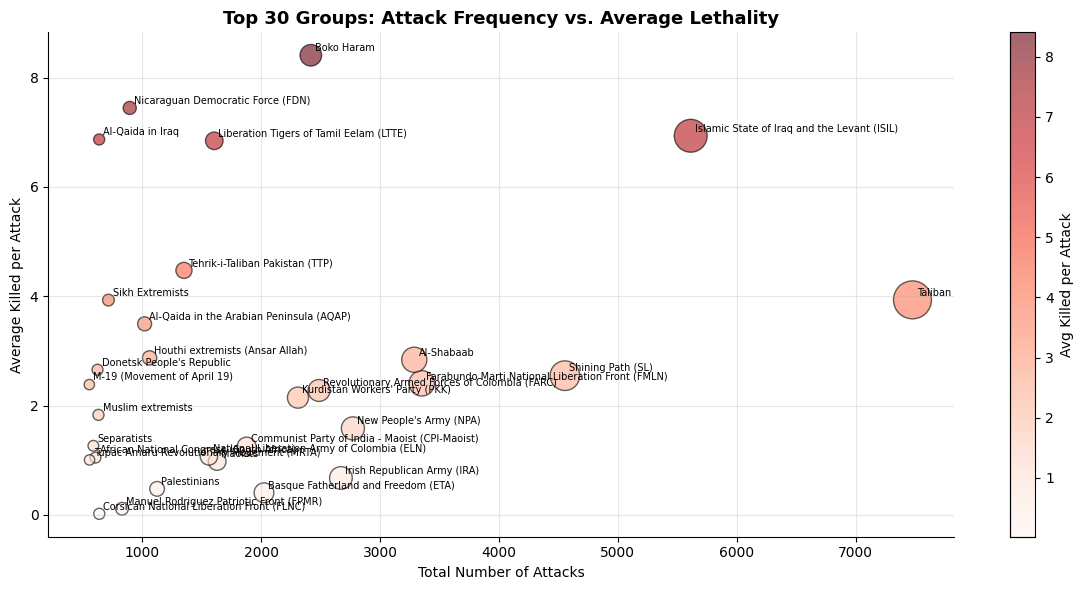

In [139]:
group_stats = (df_clean[df_clean['gname'] != 'Unknown']
               .groupby('gname')
               .agg(attacks=('eventid','count'),
                    avg_killed=('killed','mean'))
               .reset_index())

top30_groups = group_stats.nlargest(30, 'attacks')

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(top30_groups['attacks'], top30_groups['avg_killed'],
                     s=top30_groups['attacks']/10, alpha=0.6,
                     c=top30_groups['avg_killed'], cmap='Reds', edgecolors='black')
plt.colorbar(scatter, ax=ax, label='Avg Killed per Attack')

for _, row in top30_groups.iterrows():
    ax.annotate(row['gname'], (row['attacks'], row['avg_killed']),
                fontsize=7, textcoords='offset points', xytext=(3, 3))

ax.set_title('Top 30 Groups: Attack Frequency vs. Average Lethality', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Number of Attacks')
ax.set_ylabel('Average Killed per Attack')
ax.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

####**Chart - 14: Correlation Heatmap between numeric columns**

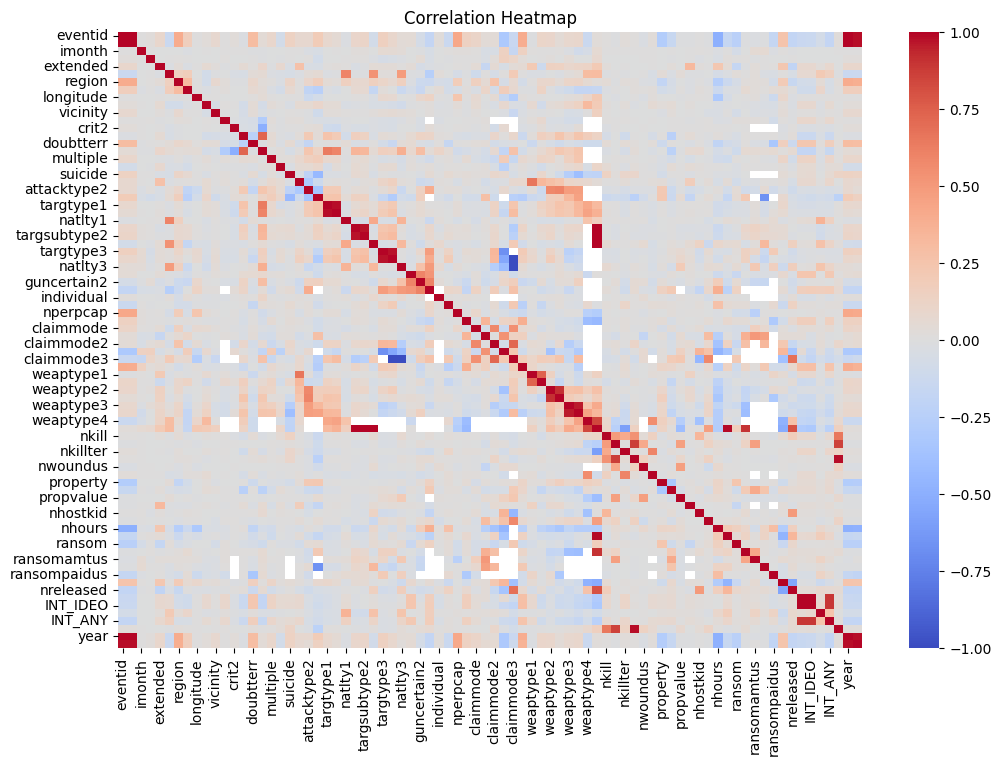

In [140]:
num_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12,8))
sns.heatmap(num_df.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()

####**Chart - 15: Pair Plot Numeric Features by Suicide Attack**

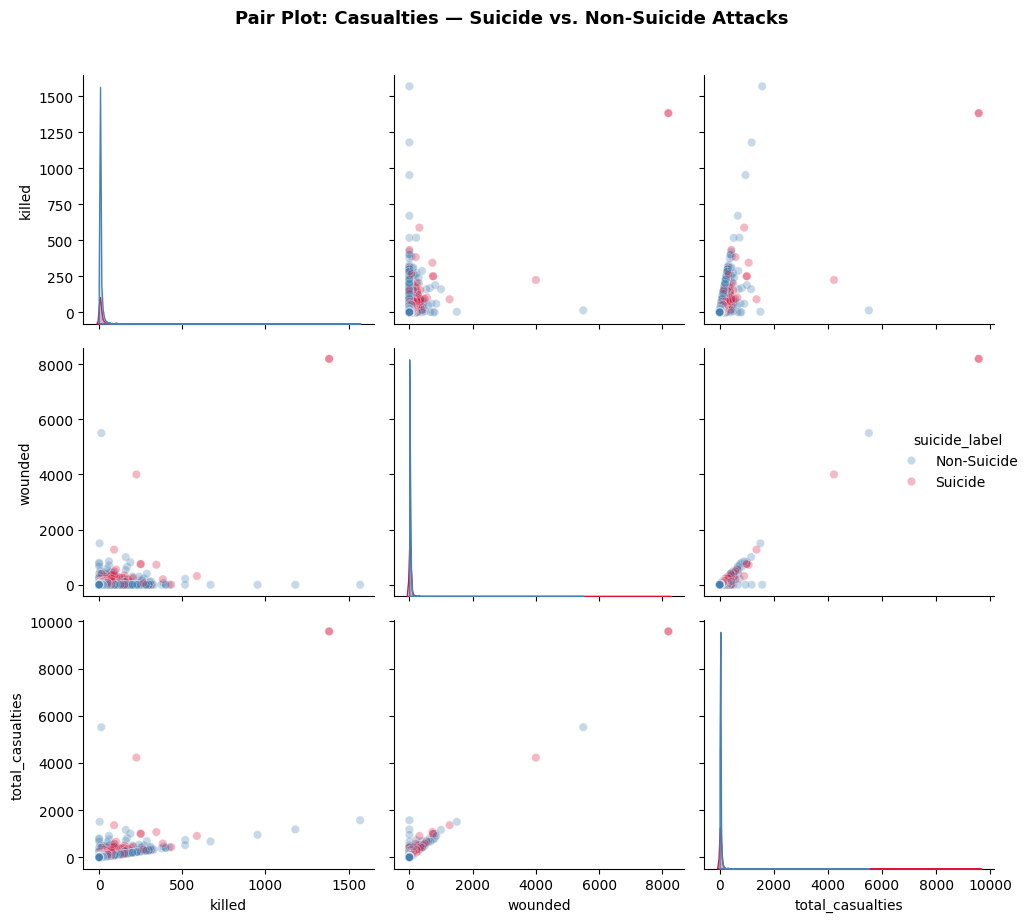

In [141]:
pair_cols = ['killed', 'wounded', 'total_casualties', 'success', 'suicide']
pair_df = df_clean[pair_cols].copy()
pair_df['suicide_label'] = pair_df['suicide'].map({0:'Non-Suicide', 1:'Suicide'})

sns.pairplot(pair_df, hue='suicide_label', vars=['killed','wounded','total_casualties'],
             palette={'Non-Suicide':'steelblue','Suicide':'crimson'},
             plot_kws={'alpha':0.3}, height=3)
plt.suptitle('Pair Plot: Casualties — Suicide vs. Non-Suicide Attacks',
             y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##***5. Hypothesis Testing***

### Hypothesis 1 — Mean Lethality: Suicide vs. Non-Suicide Attacks

- **H₀:** The mean number of people killed in suicide attacks equals the mean in non-suicide attacks.
- **H₁:** Suicide attacks have a significantly higher mean number of people killed.

In [142]:
from scipy import stats

suicide_kills    = df_clean[df_clean['suicide'] == 1]['killed']
nonsuicide_kills = df_clean[df_clean['suicide'] == 0]['killed']

print(f"Suicide attacks    — Mean Killed : {suicide_kills.mean():.2f}  | n = {len(suicide_kills):,}")
print(f"Non-suicide attacks— Mean Killed : {nonsuicide_kills.mean():.2f}  | n = {len(nonsuicide_kills):,}")

Suicide attacks    — Mean Killed : 10.13  | n = 6,633
Non-suicide attacks— Mean Killed : 1.97  | n = 175,058


In [143]:
# ── Welch's t-test (unequal variance assumed) ───────────────────────────
t_stat, p_value = stats.ttest_ind(suicide_kills, nonsuicide_kills, equal_var=False)

print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.2e}")

alpha = 0.05
if p_value < alpha:
    print(f"\nResult: Reject H₀ (p < {alpha}) → Suicide attacks ARE significantly more lethal.")
else:
    print(f"\nResult: Fail to reject H₀ (p ≥ {alpha})")

T-statistic : 21.4910
P-value     : 4.03e-99

Result: Reject H₀ (p < 0.05) → Suicide attacks ARE significantly more lethal.


**Test Used:** Welch's two-sample t-test (appropriate because sample sizes and variances differ greatly).

**Interpretation:**
- p-value ≪ 0.05 → We **reject H₀**.
- Suicide attacks cause significantly more deaths on average than non-suicide attacks.
- This confirms that suicide-attack tactics are deliberately designed for maximum lethality.

**Business Impact:** Response protocols triggered by confirmed suicide-attack incidents should automatically escalate to mass-casualty level, even before casualty counts are confirmed.

##***6. ML Model Implementation***

In [144]:
# Taking cleaned copy of the dataset for ml integration
df_ml = df_clean.copy()
df_ml.fillna('Unknown', inplace=True)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_ml.columns:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

/tmp/ipykernel_6093/2931004315.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_ml.fillna('Unknown', inplace=True)


In [145]:
# Use sample for faster training
df_ml = df_ml.sample(n=3000, random_state=42)

In [146]:
from sklearn.model_selection import train_test_split

X = df_ml.drop('attack_type', axis=1)
y = df_ml['attack_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

###**1. Logistic Regression**

In [147]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_lr = LogisticRegression(max_iter=200, solver='liblinear')

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.735


In [148]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.57      0.83      0.68       133
           1       0.37      0.17      0.23        64
           2       0.91      0.99      0.95       292
           3       0.60      0.09      0.16        33
           5       0.00      0.00      0.00         1
           6       0.54      0.31      0.39        49
           7       0.00      0.00      0.00         4
           8       0.50      0.54      0.52        24

    accuracy                           0.73       600
   macro avg       0.44      0.37      0.37       600
weighted avg       0.70      0.73      0.70       600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


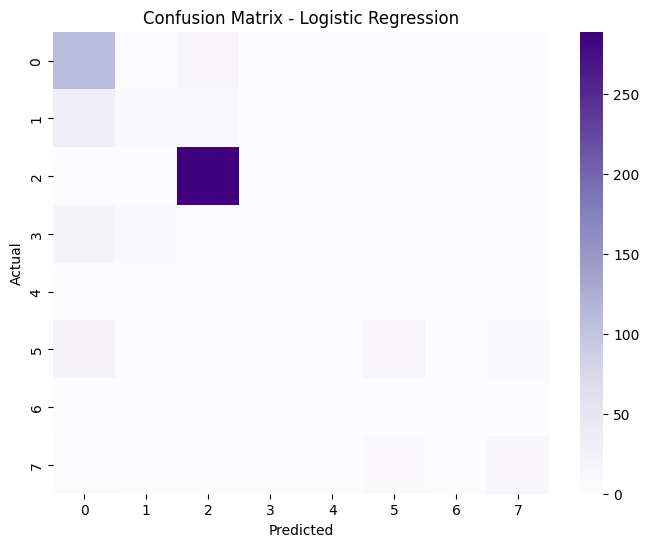

In [149]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8,6))
sns.heatmap(cm_lr, cmap='Purples', cbar=True)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Logistic Regression performs reasonably well for dominant classes such as class 2, but struggles with less frequent classes. This is due to its linear nature, which limits its ability to capture complex relationships in the data.

###**2. Decision Tree**

In [150]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(max_depth=10, random_state=42)

model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8816666666666667


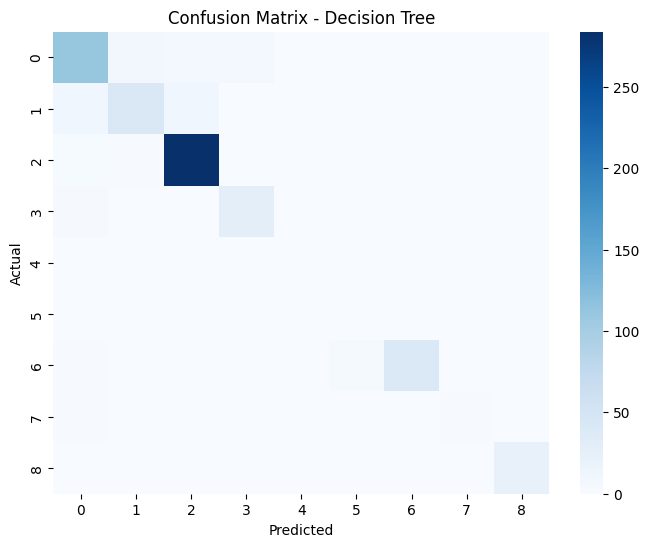

In [151]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8,6))
sns.heatmap(cm_dt, cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Decision Tree performs better than Logistic Regression by capturing non-linear patterns. It shows improved classification across multiple classes, especially for classes with moderate frequency.

###**3. Naive Bayes**

In [152]:
from sklearn.naive_bayes import GaussianNB

model_nb = GaussianNB()

model_nb.fit(X_train, y_train)

y_pred_nb = model_nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.5433333333333333


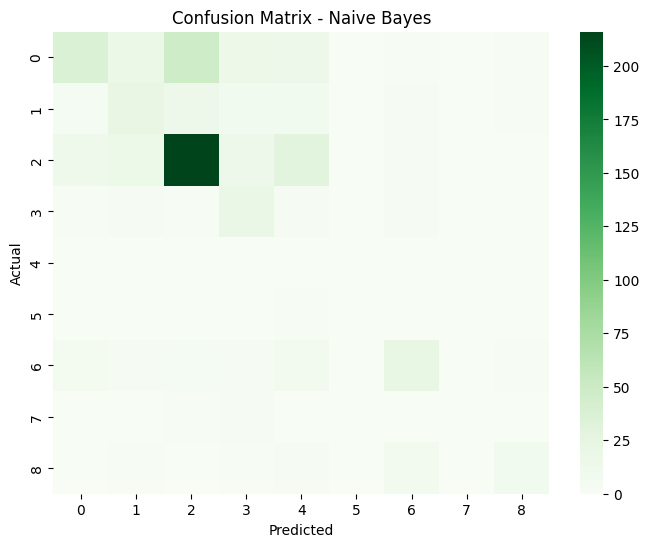

In [153]:
# Confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(8,6))
sns.heatmap(cm_nb, cmap='Greens')
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Naive Bayes performs well for dominant classes but shows limitations due to its assumption of feature independence, leading to misclassification in overlapping categories.

###**4. K Nearest Neighbours**

In [154]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [155]:
model_knn = KNeighborsClassifier(n_neighbors=5)

model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

from sklearn.metrics import accuracy_score
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.725


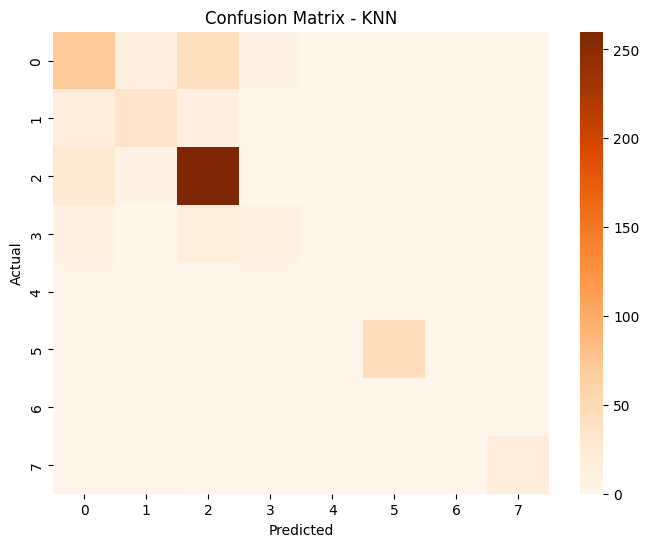

In [156]:
# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8,6))
sns.heatmap(cm_knn, cmap='Oranges')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

KNN performs well due to its distance-based approach, capturing local patterns effectively. It provides strong classification performance, especially for well-separated classes.

###**5. Agglomerative Clustering**

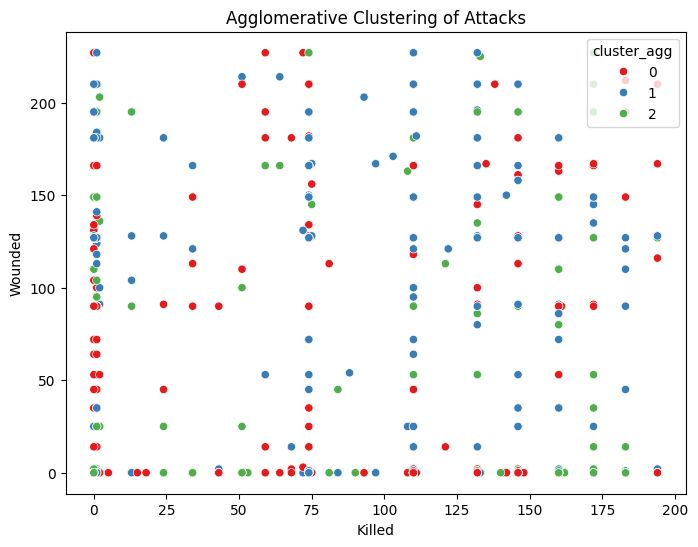

In [157]:
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=3)

df_ml['cluster_agg'] = agg.fit_predict(X)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df_ml['killed'],
    y=df_ml['wounded'],
    hue=df_ml['cluster_agg'],
    palette='Set1'
)

plt.title("Agglomerative Clustering of Attacks")
plt.xlabel("Killed")
plt.ylabel("Wounded")
plt.show()

Agglomerative Clustering was used to group similar terrorist incidents based on their features. It forms clusters hierarchically by merging similar data points, helping identify patterns in the data. Since it is an unsupervised method, accuracy and confusion matrix are not applicable.

###**6. Hierarchical clustering**

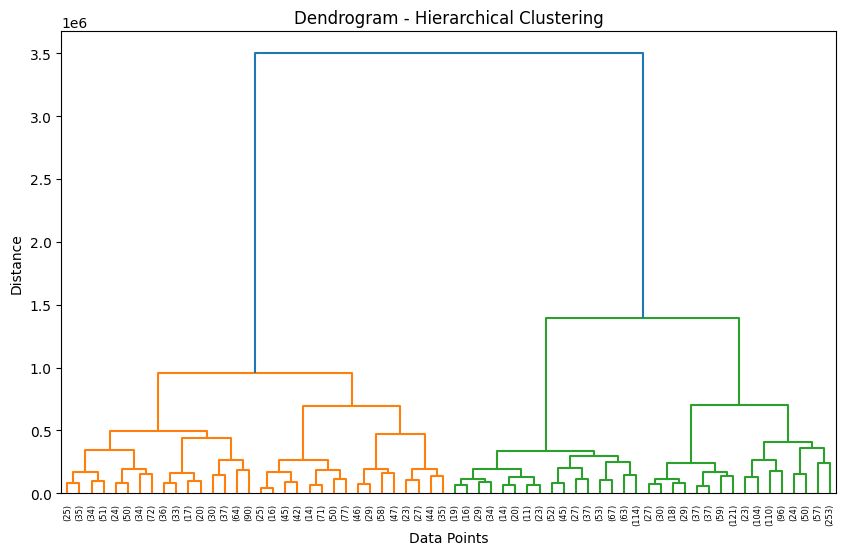

In [158]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Dendrogram - Hierarchical Clustering")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

The dendrogram shows how clusters are formed at different distance levels. It helps in deciding the number of clusters by observing where large vertical gaps occur.

###**Accuracy Comparison**

In [159]:
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Naive Bayes:", accuracy_score(y_test, y_pred_nb))
print("KNN:", accuracy_score(y_test, y_pred_knn))

Logistic Regression: 0.735
Decision Tree: 0.8816666666666667
Naive Bayes: 0.5433333333333333
KNN: 0.725


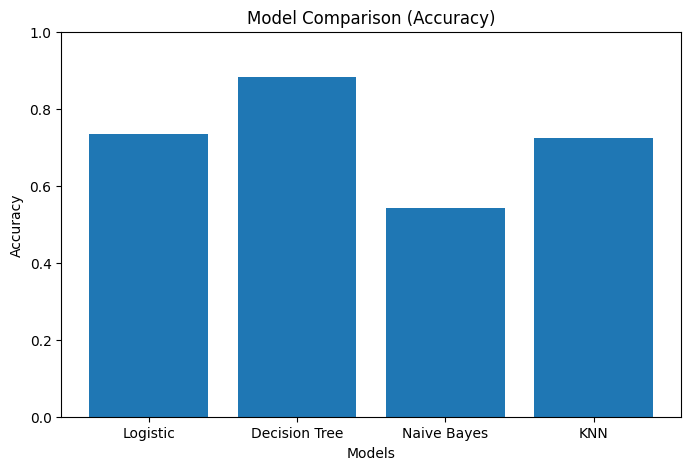

In [160]:
models = ['Logistic', 'Decision Tree', 'Naive Bayes', 'KNN']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_knn)
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Model Comparison (Accuracy)")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

# **Conclusion**

# 📊 EDA Conclusions

---
### 🔹 1. Dominant Attack Method
**Bombing and explosion** emerge as the most common attack methods across regions.
> This highlights the preference for high-impact and easily deployable attack techniques.

### 🔹 2. Temporal Surge (2011–2017)
A sharp increase in attacks is observed between **2011 and 2017**.
> This period reflects the impact of global conflicts and the rise of organized extremist groups.

### 🔹 3. Target Selection
**Civilians, military personnel, and government institutions** are the most frequent targets.
> This suggests both symbolic and strategic targeting aimed at causing widespread disruption.

### 🔹 4. Geographic Concentration
Terrorism incidents are highly concentrated in regions such as the **Middle East, South Asia, and Sub-Saharan Africa**.
> Geopolitical instability and conflict zones play a major role in driving terrorist activities.

### 🔹 5. Actor Concentration
A **small number of terrorist organizations** contribute significantly to global incidents.
> Focused intelligence efforts on key groups can have a large impact on reducing attacks.


# 🤖 ML Conclusions

---

### 🔹 1. Logistic Regression — Stable Baseline
Provides a reliable starting point for classification tasks with strong interpretability.
> Its linear nature limits its ability to capture complex, non-linear relationships in the data.



### 🔹 2. Decision Tree — Best Performer
Models non-linear patterns effectively, delivering improved accuracy and interpretability.
> Outperforms other models and offers the best balance between performance and explainability.



### 🔹 3. Naive Bayes — Fast but Moderate
Offers fast predictions with moderate performance, suitable when speed is a priority.
> The feature independence assumption reduces its effectiveness on complex, correlated datasets.



### 🔹 4. KNN — Limited by Dimensionality
Shows relatively lower performance due to high dimensionality and sensitivity to feature scaling.
> Its distance-based approach struggles when features are not well-separated.



### 🔹 5. Agglomerative & Heirarchical Clustering — Pattern Discovery
Reveal hidden groupings within the dataset through unsupervised learning.
> These methods are not evaluated on accuracy — they focus on uncovering latent structure in the data.

## ✅ Overall Conclusion

> The combination of **EDA** and **machine learning** provides both **descriptive** and **predictive** insights,
> enabling better understanding and decision-making in the context of **global terrorism**.

| Approach | Role |
|---|---|
| 📊 Exploratory Data Analysis | Uncovers patterns, trends, and distributions |
| 🤖 Supervised ML | Predicts and classifies attack-related outcomes |
| 🔵 Unsupervised ML | Reveals hidden groupings without labeled data |
| 🎯 Combined Insight | Supports informed counter-terrorism decision-making |